# Eight resonators coupled to a single transmission line

Authors: Kelvin Ramos
Description: GDS file for a system of eight resonators coupled to a single line. The width is 3um and gap is 2um for the resonators. The central line is 20um and 11um. 
(This script is to fabricate resonators with Nb and grAl)


In [1]:
# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee


# Function to find the length of lines

In [2]:
from scipy.constants import c

In [3]:
### f is float in GHz
def leng(f):
    f2=f*1e9 ## to GHz
    eff=(11.9+1)/2
    le=c/(4*np.sqrt(eff)*f2)
    le=le*1e3 # to milimeters
    return print(r'resonator length l={:.4f} mm for frequency f0={} GHz'.format(le,f))
leng(7)

resonator length l=4.2158 mm for frequency f0=7 GHz


# Chip design

Our chip design has a size of 3mm x 10mm with 200um of substrate. The dimensions of the cpw are: width=20um and gap=11um.

In [4]:
# Set up chip dimensions 
design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '10mm'
design._chips['main']['size']['size_y'] = '3mm'
design._chips['main']['size']['size_z'] = '-400um'
# design._chips['main']['size']['center_x'] = '0mm'
# design._chips['main']['size']['center_y'] = '0mm'

# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables['cpw_width_L'] = '20um' #S from reference 2
design.variables['cpw_gap_L'] = '11um' #W from reference 2
design.variables['cpw_width_R'] = '10um' #S from reference 2
design.variables['cpw_gap_R'] = '6um' #W from reference 2


design.overwrite_enabled = True

hfss = design.renderers.hfss

# Open GUI
gui = MetalGUI(design)

# Define the geometry

Here we will have a single feedline couple to 3 CPW resonators.

We need 2 lauchpads, 3 capacitors, 3 transmission lines and 3 short terminals

## Capacitors
The coupling length of our capacitors should be 115um, 102um and 85um for a resonance frequency of 6.6 GHz, 7.4 GHz and 8.45 GHz, respectively. 

In [8]:
def frecuencias(freq0,deltaf,n):
    f=[freq0]
    for i in range(n-1):
        freq0=freq0+deltaf
        f.append(freq0)
    return np.array(f)

In [9]:
### f is float in GHz
def lengt(f):
    f2=f*1e9 ## to GHz
    eff=(11.9+1)/2
    le=c/(4*np.sqrt(eff)*f2)
    le=le*1e3 # to milimeters
    return le
lengt(10)

2.9510791265256975

In [34]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# -----------------------------
# Original data
# -----------------------------
freqs = np.array([7.0, 7.1, 7.2, 7.3, 7.4,
                  7.5375, 7.675, 7.8125,
                  7.95, 8.0875, 8.225, 8.3625])

couplings = np.array([35.08, 35.34, 33.61, 32.58,
                      31.54, 30.835, 30.13,
                      29.425, 28.72, 28.205,
                      27.69, 27.18])

# -----------------------------
# Target frequencies
# -----------------------------
freq_new = np.linspace(8.1, 8.5, 8)

# -----------------------------
# Cubic interpolation
# -----------------------------
interp_func = interp1d(freqs, couplings, kind='cubic', fill_value='extrapolate')

coupling_new = interp_func(freq_new)

# -----------------------------
# Print results
# -----------------------------
for f, cup in zip(freq_new, coupling_new):
    print(f"{f:.6f} GHz  -->  coupling = {cup:.4f}")

# -----------------------------
# Plot
# -----------------------------
f_dense = np.linspace(freqs.min(), freqs.max(), 500)

plt.figure(figsize=(7,5))

plt.plot(freqs, couplings, 'o', label='Original data')
plt.plot(f_dense, interp_func(f_dense), '-', label='Interpolation')
plt.plot(freq_new, coupling_new, 's', label='New resonators')

plt.xlabel('Frequency [GHz]')
plt.ylabel('Coupling length')
plt.grid(True)
plt.legend()

plt.show()


8.100000 GHz  -->  coupling = 28.1603
8.157143 GHz  -->  coupling = 27.9491
8.214286 GHz  -->  coupling = 27.7311
8.271429 GHz  -->  coupling = 27.5127
8.328571 GHz  -->  coupling = 27.3005
8.385714 GHz  -->  coupling = 27.1008
8.442857 GHz  -->  coupling = 26.9203
8.500000 GHz  -->  coupling = 26.7653


In [35]:
freqs = np.array(freq_new); couplings = np.array(coupling_new)

### Columna 2: 5.5 GHz, 6.0 GHz, 6.5 GHz

In [36]:
lengths=lengt(freqs)
file_name=f'Eight/f_{freqs[0]}_to_{freqs[-1]}_n_{len(freqs)}_Qc_100K.gds'

fill=90
ad_coupl=fill+couplings
lenT=lengths-ad_coupl*1e-3
ad_coupl

array([118.16034985, 117.9491496 , 117.73111591, 117.51273046,
       117.30047492, 117.10083096, 116.92028024, 116.76530445])

In [37]:
###======================================================================
##### In our first experience, we have the following parameters

### for coupling_length=125um -> 75um,for 112um -> 62um, for 95um-> 45um
###

### so we need to add the fillet length to our coupling length
###======================================================================


yy_pos='1.5mm'   #capacitors' location
xx_1, xx_3, xx_5 = '1.5mm', '3.5mm', '7.5mm'
xx_2, xx_4, xx_6 = '8.5mm', '5.5mm', '4.5mm'
xx_7, xx_8= '6.5mm', '2.5mm'

##### same parameters

general=dict(prime_width='cpw_width_L', prime_gap='cpw_gap_L', second_width='cpw_width_R', 
             second_gap='cpw_gap_R', down_length='100um', fillet='90um', 
             hfss_wire_bonds=True, coupling_space='10um' )


ubi1=dict(pos_x=xx_1, pos_y=yy_pos, coupling_length=str(ad_coupl[0])+'um',
         gds_cell_name='cap_1', **general)

ubi2=dict(pos_x=xx_2, pos_y=yy_pos, coupling_length=str(ad_coupl[1])+'um',
          gds_cell_name='cap_2', orientation=180, **general)

ubi3=dict(pos_x=xx_3, pos_y=yy_pos, coupling_length=str(ad_coupl[2])+'um', 
          gds_cell_name='cap_3', **general)

ubi4=dict(pos_x=xx_4, pos_y=yy_pos, coupling_length=str(ad_coupl[3])+'um', 
          gds_cell_name='cap_4', orientation=0,**general)

ubi5=dict(pos_x=xx_5, pos_y=yy_pos, coupling_length=str(ad_coupl[4])+'um', 
          gds_cell_name='cap_5', orientation=0, **general)

ubi6=dict(pos_x=xx_6, pos_y=yy_pos, coupling_length=str(ad_coupl[5])+'um', 
          gds_cell_name='cap_6',orientation=180, **general)

ubi7=dict(pos_x=xx_7, pos_y=yy_pos, coupling_length=str(ad_coupl[6])+'um', 
          gds_cell_name='cap_7',orientation=180, **general)

ubi8=dict(pos_x=xx_8, pos_y=yy_pos, coupling_length=str(ad_coupl[7])+'um', 
          gds_cell_name='cap_8', orientation=180, **general)

Capacitor1 = CoupledLineTee(design, 'Capacitor1', options=ubi1)
Capacitor2 = CoupledLineTee(design, 'Capacitor2', options=ubi2)
Capacitor3 = CoupledLineTee(design, 'Capacitor3', options=ubi3)
Capacitor4 = CoupledLineTee(design, 'Capacitor4', options=ubi4)
Capacitor5 = CoupledLineTee(design, 'Capacitor5', options=ubi5)
Capacitor6 = CoupledLineTee(design, 'Capacitor6', options=ubi6)
Capacitor7 = CoupledLineTee(design, 'Capacitor7', options=ubi7)
Capacitor8 = CoupledLineTee(design, 'Capacitor8', options=ubi8)

gui.rebuild()
gui.autoscale()

# Launchpads
The more consistent parameter for the launchpads are width=120um and gap=61um. So that we have 50 Ohm

In [38]:
########### Launchpads position

# Driven Lauchpad 1

x1 = '0.84mm'  ## 0.0
y1 = yy_pos

# Driven Launchpad 2
x2 = '9.16mm'
y2 = yy_pos ## 2.8

general_2=dict(lead_length='10um', pad_width='250um',pad_height='400um', pad_gap='150um', 
               trace_width='cpw_width_L', trace_gap='cpw_gap_L',taper_height='340um' )

In [39]:
###################
# Single feedline #
###################


ops_1 = Dict(chip='main', pos_x=x1, pos_y=y1, orientation='360',
             gds_cell_name='LP1', **general_2)

LP1 = LaunchpadWirebondDriven(design, 'LP1', options = ops_1)


ops_2 = Dict(chip='main', pos_x=x2, pos_y=y2, orientation='180',  
            gds_cell_name='LP2', **general_2)

LP2 = LaunchpadWirebondDriven(design, 'LP2', options = ops_2)


# Rebuild the GUI
gui.rebuild()
gui.autoscale()

# Transmission lines
Here we connect the capacitors with the launchpads

In [40]:

general_3 =  dict(trace_width ='cpw_width_L', trace_gap ='cpw_gap_L', fillet='90um',
                  hfss_wire_bonds = True, chip='main',lead=Dict(end_straight='0.0mm',
                                                               gds_cell_name='linea'))

In [41]:
# Using path finder to connect the two launchpads
# Using path finder to connect the two launchpads


options_line1= Dict(                
                pin_inputs=Dict(start_pin=Dict(component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='Capacitor1',
                                                    pin='prime_start')
                                            ), **general_3)

options_line2= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor1',
                                                    pin='prime_end'),
                                                end_pin=Dict(
                                                    component='Capacitor8',
                                                    pin='prime_end')
                                            ), **general_3)


options_line3= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor8',
                                                    pin='prime_start'),
                                                end_pin=Dict(
                                                    component='Capacitor3',
                                                    pin='prime_start')
                                            ), **general_3)


options_line4= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor3',
                                                    pin='prime_end'),
                                                end_pin=Dict(
                                                    component='Capacitor6',
                                                    pin='prime_end')
                                            ), **general_3)

options_line5= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor6',
                                                    pin='prime_start'),
                                                end_pin=Dict(
                                                    component='Capacitor4',
                                                    pin='prime_start')
                                            ), **general_3)

options_line6= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor4',
                                                    pin='prime_end'),
                                                end_pin=Dict(
                                                    component='Capacitor7',
                                                    pin='prime_end')
                                            ), **general_3)

options_line7= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor7',
                                                    pin='prime_start'),
                                                end_pin=Dict(
                                                    component='Capacitor5',
                                                    pin='prime_start')
                                            ), **general_3)

options_line8= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor5',
                                                    pin='prime_end'),
                                                end_pin=Dict(
                                                    component='Capacitor2',
                                                    pin='prime_end')
                                            ), **general_3)


options_line9= Dict(
                pin_inputs=Dict(start_pin=Dict(component='Capacitor2',
                                                    pin='prime_start'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            ), **general_3)


line1 = RoutePathfinder(design, 'line1', options = options_line1)
line2= RoutePathfinder(design, 'line2', options = options_line2)
line3 = RoutePathfinder(design, 'line3', options = options_line3)
line4 = RoutePathfinder(design, 'line4', options = options_line4)
line5 = RoutePathfinder(design, 'line5', options = options_line5)
line6 = RoutePathfinder(design, 'line6', options = options_line6)
line7 = RoutePathfinder(design, 'line7', options = options_line7)
line8 = RoutePathfinder(design, 'line8', options = options_line8)
line9 = RoutePathfinder(design, 'line9', options = options_line9)



# Rebuild the GUI
gui.rebuild()
gui.autoscale()

# Resonators
The resonators are lambda/4 and each of them has a length of 4.5mm, 4.0mm  and 3.5mm.  

In [46]:
general_4= dict(chip='main',trace_width ='cpw_width_R', gds_cell_name='meandro', trace_gap ='cpw_gap_R', hfss_wire_bonds = True, fillet='50um',
               meander=Dict(spacing='105um', asymmetry='0um'),
               lead = Dict(start_straight='100um', end_straight='10um'))

In [43]:
######################
# lambda/4 resonator #
######################

# First we define the two end-points
#otg1 = OpenToGround(design, 'otg1', options=Dict(chip='main', pos_x='2.0 mm',  pos_y='2.748', orientation='-180',
                                                 #width='20um', gap='11um', termination_gap='11 um'))
yy_fin='0.62mm'
yy_fin2='2.38mm'

otg1 = ShortToGround(design, 'otg1', options=Dict(chip='main', pos_x=xx_1,  pos_y=yy_fin, orientation='0'))                                                   #width='20um', gap='11um', termination_gap='11 um'))
otg2 = ShortToGround(design, 'otg2', options=Dict(chip='main', pos_x=xx_2,  pos_y=yy_fin2, orientation='180'))                                                   #width='20um', gap='11um', termination_gap='11 um'))
otg3 = ShortToGround(design, 'otg3', options=Dict(chip='main', pos_x=xx_3,  pos_y=yy_fin, orientation='0'))
otg4 = ShortToGround(design, 'otg4', options=Dict(chip='main', pos_x=xx_4,  pos_y=yy_fin, orientation='180'))
otg5 = ShortToGround(design, 'otg5', options=Dict(chip='main', pos_x=xx_5,  pos_y=yy_fin, orientation='0'))
otg6 = ShortToGround(design, 'otg6', options=Dict(chip='main', pos_x=xx_6,  pos_y=yy_fin2, orientation='180'))
otg7 = ShortToGround(design, 'otg7', options=Dict(chip='main', pos_x=xx_7,  pos_y=yy_fin2, orientation='0'))
otg8 = ShortToGround(design, 'otg8', options=Dict(chip='main', pos_x=xx_8,  pos_y=yy_fin2, orientation='180'))


# Use RouteMeander to fix the total length of the resonator
####===================================================================================

options_meandro1= Dict(total_length=str(lenT[0])+'mm', 
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor1', pin='second_end'),
                              end_pin=Dict(component='otg1', pin='short')), **general_4)

options_meandro2= Dict( total_length=str(lenT[1])+'mm',
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor2', pin='second_end'),
                              end_pin=Dict(component='otg2', pin='short')), **general_4)

options_meandro3= Dict(total_length=str(lenT[2])+'mm', 
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor3', pin='second_end'),
                              end_pin=Dict(component='otg3', pin='short')), **general_4)

options_meandro4= Dict( total_length=str(lenT[3])+'mm',
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor4', pin='second_end'),
                              end_pin=Dict(component='otg4', pin='short')), **general_4)

options_meandro5= Dict(total_length=str(lenT[4])+'mm', 
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor5', pin='second_end'),
                              end_pin=Dict(component='otg5', pin='short')), **general_4)

options_meandro6= Dict(total_length=str(lenT[5])+'mm', 
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor6', pin='second_end'),
                              end_pin=Dict(component='otg6', pin='short')), **general_4)

options_meandro7= Dict(total_length=str(lenT[6])+'mm', 
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor7', pin='second_end'),
                              end_pin=Dict(component='otg7', pin='short')), **general_4)

options_meandro8= Dict(total_length=str(lenT[7])+'mm', 
                  pin_inputs=Dict(
                              start_pin=Dict(component='Capacitor8', pin='second_end'),
                              end_pin=Dict(component='otg8', pin='short')), **general_4)


meandro1 = RouteMeander(design, 'meandro1',  options=options_meandro1)
meandro2 = RouteMeander(design, 'meandro2',  options=options_meandro2)
meandro3 = RouteMeander(design, 'meandro3',  options=options_meandro3)
meandro4 = RouteMeander(design, 'meandro4',  options=options_meandro4)
meandro5 = RouteMeander(design, 'meandro5',  options=options_meandro5)
meandro6 = RouteMeander(design, 'meandro6',  options=options_meandro6)
meandro7 = RouteMeander(design, 'meandro7',  options=options_meandro7)
meandro8 = RouteMeander(design, 'meandro8',  options=options_meandro8)

# rebuild the GUI
gui.rebuild()
gui.autoscale()

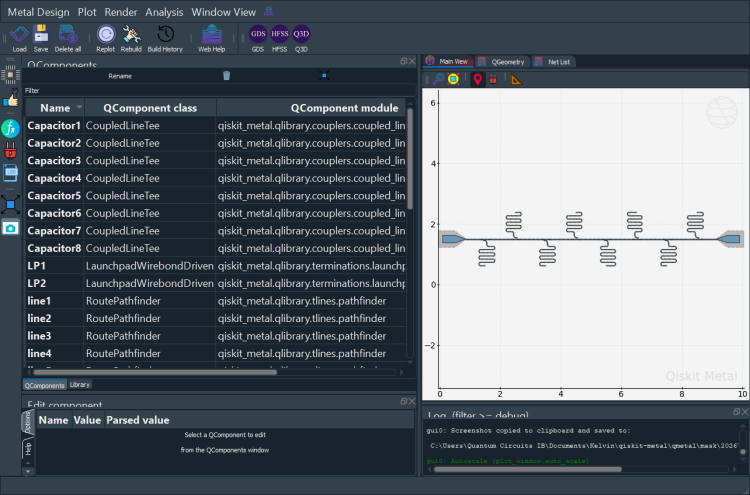

In [45]:
gui.autoscale()
gui.screenshot()

# Export Gds

In [56]:
a_gds = design.renderers.gds
### import and place the cell names in the Fake_Junctions
a_gds.options['path_filename'] = 'Fake_Junctions.GDS'

In [57]:
## for fillet the short segments, True means no fillet
a_gds.options['short_segments_to_not_fillet'] = 'False'

scale_fillet = 2.0
a_gds.options['check_short_segments_by_scaling_fillet'] = scale_fillet

In [59]:
# Restore a_gds options

a_gds.options.no_cheese['view_in_file']['main']={1: False}
a_gds.options.cheese['view_in_file']['main']={1: False}
a_gds.options['max_points'] = '8191'
a_gds.options['no_cheese']['buffer']='50um'
# We will shift the center of the chip to origin

design.chips.main.size['center_x'] = '5.0mm'
design.chips.main.size['center_y'] = '1.5mm'
design.rebuild()

### For demo, set max_points to 8191 and look at the GDS output.
a_gds.options['max_points'] = '8191'

# We next export it to GDS

design.renderers.gds.export_to_gds(file_name)

05:15PM 04s WARNING [_import_junction_gds_file]: Not able to find file:"Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"C:\Users\Quantum Circuits IB\Documents\Kelvin\qiskit-metal\qmetal\mask\2026".


1

In [209]:
#Many ways to view the QGeometry tables.
#If you want to view, uncomment below lines and and run it.

#design.qgeometry.tables
#design.qgeometry.tables['path']
#design.qgeometry.tables['poly']

# EPR

In [47]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_res = EPRanalysis(design, "hfss")

In [48]:
hfss = eig_res.sim.renderer

In [49]:
hfss.start() ## start hfss

INFO 04:29PM [connect_project]: Connecting to Ansys Desktop API...
INFO 04:29PM [load_ansys_project]: 	Opened Ansys App
INFO 04:29PM [load_ansys_project]: 	Opened Ansys Desktop v2018.0.0
INFO 04:29PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Quantum Circuits IB/Documents/Kelvin/mediciones/Simu/data/kin/s21_runs/two_resonators/
	Project:   Project32
INFO 04:29PM [connect_design]: 	Opened active design
	Design:    First_1_Al_Nb [Solution type: DrivenModal]
INFO 04:29PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 04:29PM [connect]: 	Connected to project "Project32" and design "First_1_Al_Nb" 😀 



True

In [118]:
# clean the design if needed
hfss.clean_active_design()

In [52]:
hfss.activate_ansys_design("EPR-R-8_v3", 'eigenmode')  # use new_ansys_design() to force creation of a blank design

04:29PM 53s WARNING [activate_ansys_design]: The design_name=EPR-R-8_v3 was not in active project.  Designs in active project are: 
['EPR-R-8_v2', 'First_1_Al', 'First_1_Al_Nb', 'Readout_R3-0011_g'].  A new design will be added to the project.  
INFO 04:29PM [connect_design]: 	Opened active design
	Design:    EPR-R-8_v3 [Solution type: Eigenmode]
WARNING 04:29PM [connect_setup]: 	No design setup detected.
WARNING 04:29PM [connect_setup]: 	Creating eigenmode default setup.
INFO 04:29PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


In [53]:
hfss.render_design([], [])
#hfss.save_screenshot()

In [ ]:
# Analysis properties
setup = hfss.pinfo.setup
setup.passes = 14
setup.delta_f= 0.1
setup.n_modes= 4
print(f"""
Number of eigenmodes to find             = {setup.n_modes}
Number of simulation passes              = {setup.passes}
Convergence freq max delta percent diff  = {setup.delta_f}
""")

# Next 2 lines are counterinuitive, since there is no junction in this resonator.
# However, these are necessary to make pyEPR work correctly. Please do note delete
hfss.pinfo.design.set_variable('Lj', '10 nH')
hfss.pinfo.design.set_variable('Cj', '0 fF')
setup.analyze()

In [ ]:
eig_res.sim.convergence_t, eig_res.sim.convergence_f, _ = hfss.get_convergences()
eig_res.sim.plot_convergences()

# Scattering Analysis

In [93]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
em1 = ScatteringImpedanceSim(design, "hfss")

In [94]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('LP1', 'in', 50),
             ('LP2', 'in', 50)]
box_plus_buffer = True

In [95]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

INFO 01:19PM [connect_project]: Connecting to Ansys Desktop API...
INFO 01:19PM [load_ansys_project]: 	Opened Ansys App
INFO 01:19PM [load_ansys_project]: 	Opened Ansys Desktop v2018.0.0
INFO 01:19PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Quantum Circuits IB/Documents/Kelvin/mediciones/Simu/data/kin/
	Project:   8R
INFO 01:19PM [connect_design]: 	Opened active design
	Design:    resonators_8 [Solution type: DrivenModal]
INFO 01:19PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 01:19PM [connect]: 	Connected to project "8R" and design "resonators_8" 😀 



True

In [96]:
# Here we activate the design for a drivenmodal solution
hfss.activate_ansys_design("resonators_8_v2", 'drivenmodal')
setup_args = Dict(max_delta_s=0.02)
setup_args.name = 'Setup'
hfss.edit_drivenmodal_setup(setup_args)

01:19PM 34s WARNING [activate_ansys_design]: The design_name=resonators_8_v2 was not in active project.  Designs in active project are: 
['Readout-8R', 'resonators_8'].  A new design will be added to the project.  
INFO 01:19PM [connect_design]: 	Opened active design
	Design:    resonators_8_v2 [Solution type: DrivenModal]
WARNING 01:19PM [connect_setup]: 	No design setup detected.
WARNING 01:19PM [connect_setup]: 	Creating driven modal default setup.
INFO 01:19PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
01:19PM 36s WARNING [edit_drivenmodal_setup]: In setup_args, key=max_delta_s, value=0.02 is not in pinfo.setup, the key/value pair from setup_args not added to Setup in Ansys.


In [97]:
# set buffer
hfss.options['x_buffer_width_mm'] = 0.4
hfss.options['y_buffer_width_mm'] = 0.4

In [53]:
# clean the design if needed
hfss.clean_active_design()

In [ ]:
# render the design
hfss.render_design(selection=[], 
                   open_pins=open_terminations, 
                   port_list=port_list, 
                   box_plus_buffer = box_plus_buffer)

In [37]:
# # for acurate simulations, make sure the mesh is fine enough for the meander
# hfss.modeler.mesh_length(
#                 'cpw_mesh',
#                 ['trace_lineac','trace_lineab','trace_lineaa',
#                  'trace_linea','trace_meandro', 'trace_meandroa','trace_meandrob',
#                  'prime_cpw_Capacitora', 'prime_cpw_Capacitorb', 'prime_cpw_Capacitor',
#                  'launch_pad_LP2', 'launch_pad_LP1', 'second_cpw_Capacitora',
#                  'second_cpw_Capacitorb', 'second_cpw_Capacitor'],
#                 MaxLength='0.01mm')

In [42]:
# for acurate simulations, make sure the mesh is fine enough for the meander
hfss.modeler.mesh_length(
                'cpw_mesh',
                ['trace_meandro', 'trace_meandroa','trace_meandrob', 
                 'second_cpw_Capacitor','second_cpw_Capacitora','second_cpw_Capacitorb'],
                MaxLength='0.01mm')

In [212]:
# hfss.modeler.mesh_length(
#                 'cpw_plane',
#                 ['trace_meandro','trace_meandroa','trace_meandrob'],
#                 MaxLength='10um')

# Broad sweet to find the resonance

In [55]:
hfss.add_sweep(setup_name="Setup", 
               name="Sweep", 
               start_ghz=6.5,
               stop_ghz=8.5,
               count=2001,
               type="Fast")

INFO 12:07AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [29]:
hfss.analyze_sweep('Sweep', 'Setup')

INFO 10:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 10:08PM [analyze]: Analyzing setup Setup : Sweep


In [ ]:
hfss.plot_params(['S11', 'S21'])

In [ ]:
# extract the S21 parameters
freqs, Pcurves, Pparams = hfss.get_params(['S21'])

In [ ]:
# find armin 
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res

# Narrow sweep around the resonance found above

In [ ]:
#fine sweep
hfss.add_sweep(setup_name="Setup", 
               name="Sweep_narrow", 
               start_ghz=np.round(f_res/1e9,3)-0.01,
               stop_ghz=np.round(f_res/1e9,3)+0.01,
               count=1001,
               type="Fast") #slow but precise

In [ ]:
hfss.analyze_sweep('Sweep_narrow', 'Setup')

In [ ]:
hfss.plot_params(['S11', 'S21'])

# Close connections

In [47]:
em1.close()

Warning! 3 COM references still alive
Ansys will likely refuse to shut down


In [58]:
hfss.disconnect_ansys()

Warning! 3 COM references still alive
Ansys will likely refuse to shut down


In [50]:
gui.main_window.close()

True

In [ ]:
close()

In [46]:
import qiskit_metal
qiskit_metal.__version__

'0.0.4'